In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, roc_curve, auc,
                             mean_absolute_error, mean_squared_error, r2_score)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import joblib
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
print("Imported!!")

Imported!!


In [2]:
df=pd.read_csv("clean_df.csv")
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
884,0,2,male,27.0,0,0,13.0000,S
885,1,1,female,19.0,0,0,30.0000,S
886,0,3,female,28.0,1,2,23.4500,S
887,1,1,male,26.0,0,0,30.0000,C


Outlier in fare: 512.3292


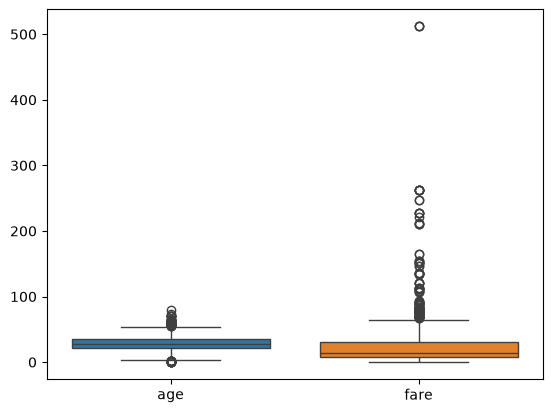

In [7]:
# check for outliers in age and fare columns
sns.boxplot(df[["age", "fare"]])
outlier_fare = df["fare"].max()
print("Outlier in fare:",outlier_fare)

There is one purticular outlier for fare which is very far from other outliers where fare > 500.
as this is a single instance of fare being > 500 and other ones are in the range of <300 this might be an invalid entry and can be removed.

after removing the outlier


<Axes: >

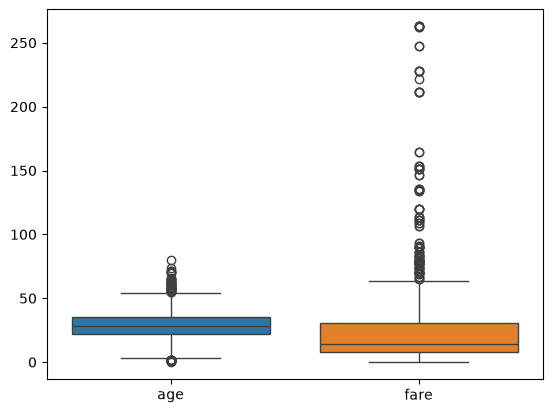

In [8]:
# remove the record for this outlier
df = df[df["fare"] != 512.3292]
print("after removing the outlier")
sns.boxplot(df[["age", "fare"]])

In [10]:
# Preprocessing
X = df.drop(columns=["survived"])
y = df["survived"]
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2,stratify=y)
print("Training data:",X_train.shape)
print("Testing data:",X_test.shape)
print("Training Target:",y_train.value_counts())
print("Testing Target:",y_test.value_counts())

Training data: (708, 7)
Testing data: (178, 7)
Training Target: survived
0    439
1    269
Name: count, dtype: int64
Testing Target: survived
0    110
1     68
Name: count, dtype: int64


In [11]:
# create column transformer
categorial_cols = ["sex", "embarked"]
numerical_cols = ["age", "fare"]
col_transformer = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(), categorial_cols)
    ],
    remainder='passthrough'
)
col_transformer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

In [12]:
# Getting three models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=6),
    "Random Forest": RandomForestClassifier(random_state=42, max_depth=6, n_estimators=50)
}
stats = {}
for i, model in models.items():
    stats[i] = {}
    pipe = Pipeline(steps=[
        ('preprocessor', col_transformer),
        ('model', model)
    ])

    print(f"Training the Model - {i}....")
    pipe.fit(X_train, y_train)

    print(f"Testing with Training data....")
    y_train_pred = pipe.predict(X_train)
    y_train_proba = pipe.predict_proba(X_train)

    stats[i]["Train Accuracy"] = accuracy_score(y_train, y_train_pred)
    stats[i]["Train Precision"] = precision_score(y_train, y_train_pred)
    stats[i]["Train Recall"] = recall_score(y_train, y_train_pred)
    stats[i]["Train F1 Score"] = f1_score(y_train, y_train_pred)
    stats[i]["Train CM"] = confusion_matrix(y_train, y_train_pred)
    stats[i]["Train Probabilities"] = y_train_proba[:1]

    print(f"Testing with Test data....")
    y_test_pred = pipe.predict(X_test)
    y_test_proba = pipe.predict_proba(X_test)

    stats[i]["Test Accuracy"] = accuracy_score(y_test, y_test_pred)
    stats[i]["Test Precision"] = precision_score(y_test, y_test_pred)
    stats[i]["Test Recall"] = recall_score(y_test, y_test_pred)
    stats[i]["Test F1 Score"] = f1_score(y_test, y_test_pred)
    stats[i]["Test CM"] = confusion_matrix(y_test, y_test_pred)
    stats[i]["Test Probabilities"] = y_test_proba[:, 1]
    
print("-" * 80)
print(f"{"Metric":<20}{"Logistic Regression":<25}{"Decision Tree":<20}{"Random Forest":<20}")
print("-" * 80)
metric_labels = [i for i in stats["Logistic Regression"]]
for label in metric_labels:
    if label not in ["Test CM", "Test Probabilities", "Train CM", "Train Probabilities"]:
        print(f"{label:<20}{round(stats["Logistic Regression"][label], 4):<25}{round(stats["Decision Tree"][label],4):<20}{round(stats["Random Forest"][label], 4)}")

Training the Model - Logistic Regression....
Testing with Training data....
Testing with Test data....
Training the Model - Decision Tree....
Testing with Training data....
Testing with Test data....
Training the Model - Random Forest....
Testing with Training data....
Testing with Test data....
--------------------------------------------------------------------------------
Metric              Logistic Regression      Decision Tree       Random Forest       
--------------------------------------------------------------------------------
Train Accuracy      0.8093                   0.8771              0.887
Train Precision     0.7597                   0.8856              0.8921
Train Recall        0.7286                   0.777               0.7993
Train F1 Score      0.7438                   0.8277              0.8431
Test Accuracy       0.7697                   0.7416              0.7978
Test Precision      0.7547                   0.6667              0.7857
Test Recall         0.58

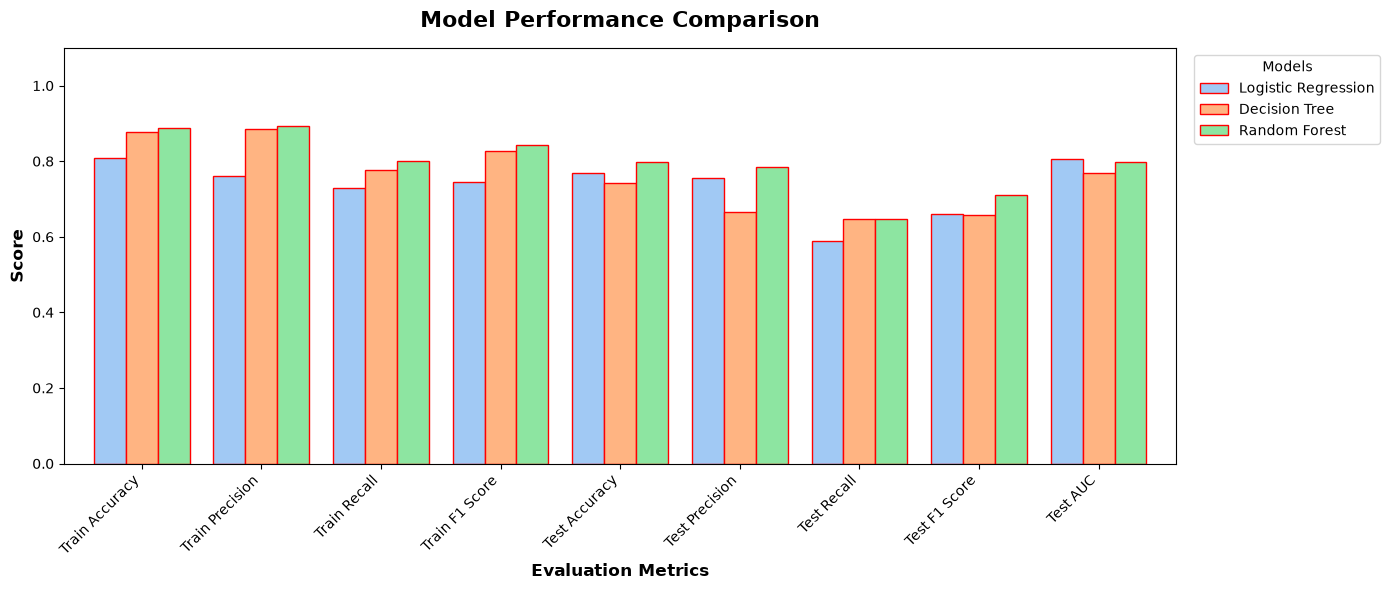

In [ ]:
# displaying evaluation metrics
filtered_stats = {}
for model, model_data in stats.items():
    y_proba = model_data["Test Probabilities"]
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    model_auc = auc(fpr, tpr)

    filtered_stats[model] = {
        metric_name: value 
        for metric_name, value in model_data.items() if 'CM' not in metric_name and 'Probabilities' not in metric_name
    }
    filtered_stats[model]["Test AUC"] = model_auc
df_metrics = pd.DataFrame(filtered_stats)
fig, ax = plt.subplots(figsize=(14, 6))
df_metrics.plot(kind='bar', ax=ax, width=0.8, color=sns.color_palette("pastel"), edgecolor='red')
ax.set_title('Model Performance Comparison', fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('Score', fontweight='bold', fontsize=12)
ax.set_xlabel('Evaluation Metrics', fontweight='bold', fontsize=12)
ax.set_ylim(0, 1.1) 
plt.xticks(rotation=45, ha='right')
ax.legend(title='Models', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

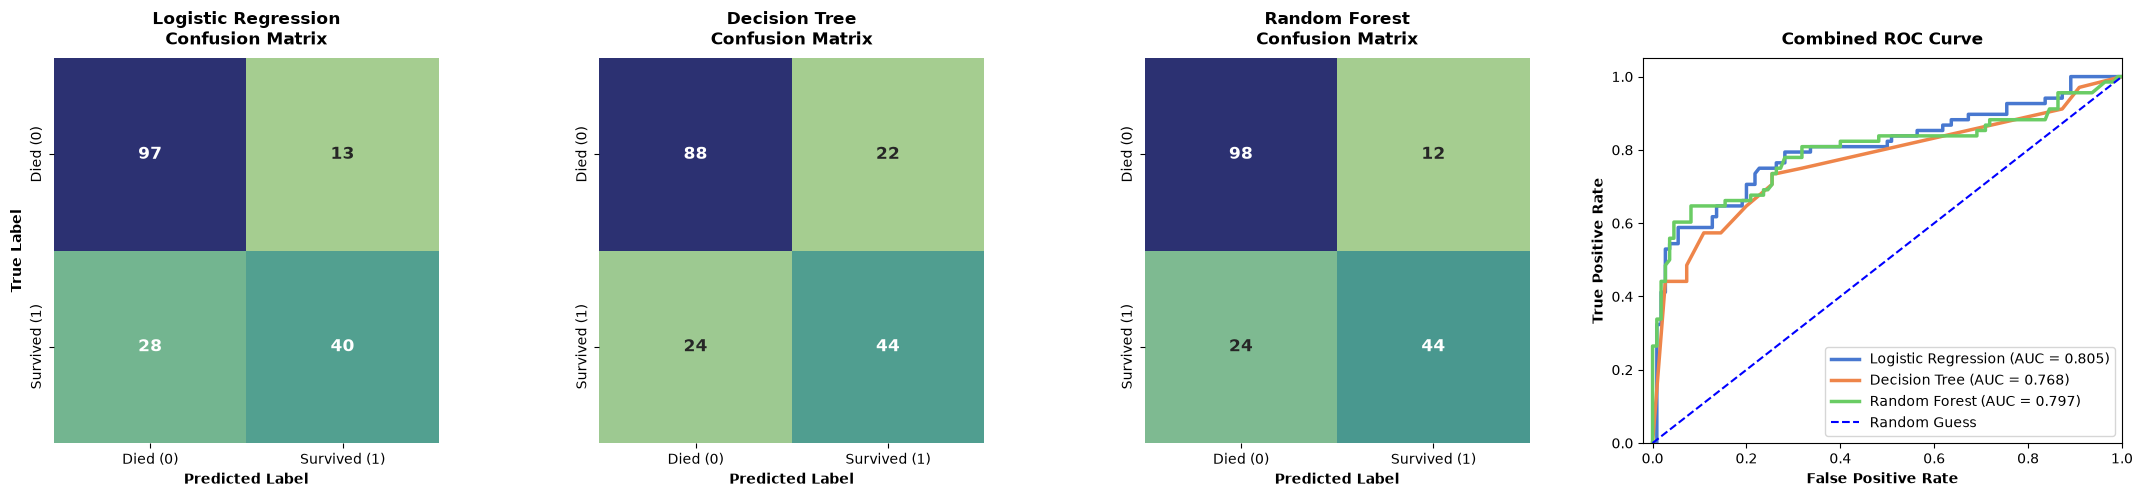

In [22]:
# display confusion matrix and RoC curve
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(22, 5))
for idx, (model_name, model_metrics) in enumerate(stats.items()):
    ax = axes[idx]
    cm = model_metrics["Test CM"]
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='crest', ax=ax, 
                cbar=False, square=True, annot_kws={"size": 12, "weight": "bold"},
                xticklabels=['Died (0)', 'Survived (1)'], 
                yticklabels=['Died (0)', 'Survived (1)'])
    
    ax.set_title(f'{model_name}\nConfusion Matrix', fontweight='bold', pad=10)
    ax.set_xlabel('Predicted Label', fontweight='bold')
    if idx == 0:
        ax.set_ylabel('True Label', fontweight='bold')
ax_roc = axes[3]
roc_colors = sns.color_palette("muted", 3)

for idx, (model_name, model_metrics) in enumerate(stats.items()):
    # Extract the probabilities you saved earlier
    y_proba = model_metrics["Test Probabilities"]
    
    # Calculate ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    # Plot each model's line on the same axis
    ax_roc.plot(fpr, tpr, color=roc_colors[idx], lw=2.5, label=f'{model_name} (AUC = {roc_auc:.3f})')
ax_roc.plot([0, 1], [0, 1], color='blue', lw=1.5, linestyle='--', label='Random Guess')
ax_roc.set_xlim([-0.02, 1.0])
ax_roc.set_ylim([0.0, 1.05])
ax_roc.set_xlabel('False Positive Rate', fontweight='bold')
ax_roc.set_ylabel('True Positive Rate', fontweight='bold')
ax_roc.set_title('Combined ROC Curve', fontweight='bold', pad=10)
ax_roc.legend(loc="lower right", frameon=True, fontsize=10)
plt.tight_layout()
plt.show()

In [26]:
# Imbalance handling comparision
#knowing imbalances
percent_of_positives = (df[df["survived"] == 1].shape[0] / df.shape[0]) * 100
print(f"Percentage of survived records - {round(percent_of_positives, 2)}")
# Using earlier base linear regression model evaluation stats train the new linear regression model using model weights
pipe_weighted = Pipeline(
    steps=[
        ('preprocessor', col_transformer),
        ('model', LogisticRegression(class_weight='balanced'))
    ]
)
print(f"Training the Model - Weighted LR....")
pipe_weighted.fit(X_train, y_train)

print(f"Testing with Training data....")
y_train_weights_pred = pipe_weighted.predict(X_train)

stats_2 = {}
stats_2["Weighted LR"] = {}

stats_2["Weighted LR"]["Train Accuracy"] = accuracy_score(y_train, y_train_weights_pred)
stats_2["Weighted LR"]["Train Precision"] = precision_score(y_train, y_train_weights_pred)
stats_2["Weighted LR"]["Train Recall"] = recall_score(y_train, y_train_weights_pred)
stats_2["Weighted LR"]["Train F1 Score"] = f1_score(y_train, y_train_weights_pred)

print(f"Testing with Test data....")
print("-" * 10)
y_test_weights_pred = pipe_weighted.predict(X_test)

stats_2["Weighted LR"]["Test Accuracy"] = accuracy_score(y_test, y_test_weights_pred)
stats_2["Weighted LR"]["Test Precision"] = precision_score(y_test, y_test_weights_pred)
stats_2["Weighted LR"]["Test Recall"] = recall_score(y_test, y_test_weights_pred)
stats_2["Weighted LR"]["Test F1 Score"] = f1_score(y_test, y_test_weights_pred)

# Oversample with SMOTE and again applying linear regression model with smote oversampling data
pipe_smote = ImbPipeline(
    steps=[
        ('preprocessor', col_transformer),
        ('smote', SMOTE(random_state=42)),
        ('model', LogisticRegression())
    ]
)
print(f"Training the Model - smote data....")
pipe_smote.fit(X_train, y_train)

print(f"Testing with Training data....")
y_train_smote_pred = pipe_smote.predict(X_train)

stats_2["SMOTE LR"] = {}

stats_2["SMOTE LR"]["Train Accuracy"] = accuracy_score(y_train, y_train_smote_pred)
stats_2["SMOTE LR"]["Train Precision"] = precision_score(y_train, y_train_smote_pred)
stats_2["SMOTE LR"]["Train Recall"] = recall_score(y_train, y_train_smote_pred)
stats_2["SMOTE LR"]["Train F1 Score"] = f1_score(y_train, y_train_smote_pred)

print(f"Testing with Test data....")
print("-" * 10)
y_test_smote_pred = pipe_smote.predict(X_test)

stats_2["SMOTE LR"]["Test Accuracy"] = accuracy_score(y_test, y_test_smote_pred)
stats_2["SMOTE LR"]["Test Precision"] = precision_score(y_test, y_test_smote_pred)
stats_2["SMOTE LR"]["Test Recall"] = recall_score(y_test, y_test_smote_pred)
stats_2["SMOTE LR"]["Test F1 Score"] = f1_score(y_test, y_test_smote_pred)

# Comparing results of all three models
print("Testing Results")
print("-" * 80)
print(f"{"Metric":<20}{"BaseLine LR":<25}{"Weighted LR":<20}{"SMOTE LR":<20}")
print("-" * 80)
for_plot = {
    "Baseline LR":{},
    "Weighted LR": {},
    "SMOTE LR": {}
}
metrics_for_comparision = ["Train Accuracy", "Train Precision", "Train Recall", "Train F1 Score", "Test Accuracy", "Test Precision", "Test Recall", "Test F1 Score"]
for metric in metrics_for_comparision:
    base_lr = round(stats["Logistic Regression"][metric], 4)
    for_plot["Baseline LR"][metric] = base_lr
    weight_lr = round(stats_2["Weighted LR"][metric],4)
    for_plot["Weighted LR"][metric] = weight_lr
    smote_lr = round(stats_2["SMOTE LR"][metric],4)
    for_plot["SMOTE LR"][metric] = smote_lr
    print(f"{metric:<20}{base_lr:<25}{weight_lr:<20}{smote_lr}")

Percentage of survived records - 38.04
Training the Model - Weighted LR....
Testing with Training data....
Testing with Test data....
----------
Training the Model - smote data....
Testing with Training data....
Testing with Test data....
----------
Testing Results
--------------------------------------------------------------------------------
Metric              BaseLine LR              Weighted LR         SMOTE LR            
--------------------------------------------------------------------------------
Train Accuracy      0.8093                   0.7895              0.7867
Train Precision     0.7597                   0.7027              0.7007
Train Recall        0.7286                   0.7732              0.7658
Train F1 Score      0.7438                   0.7363              0.7318
Test Accuracy       0.7697                   0.7528              0.764
Test Precision      0.7547                   0.6765              0.7097
Test Recall         0.5882                   0.6765    

Instantiate the RandomForestClassifier pipeline
Initialising the grid search object.....
Performing Grid Search....
Best Parameters: {'model__max_depth': 10, 'model__n_estimators': 50}
Best F1 Score: 0.7758053152233072
----------
Instantiate the random forest clasifier with these parametres
Train the best fit model....
Testing with Training data....
Testing with Test data....
Publishing Results...


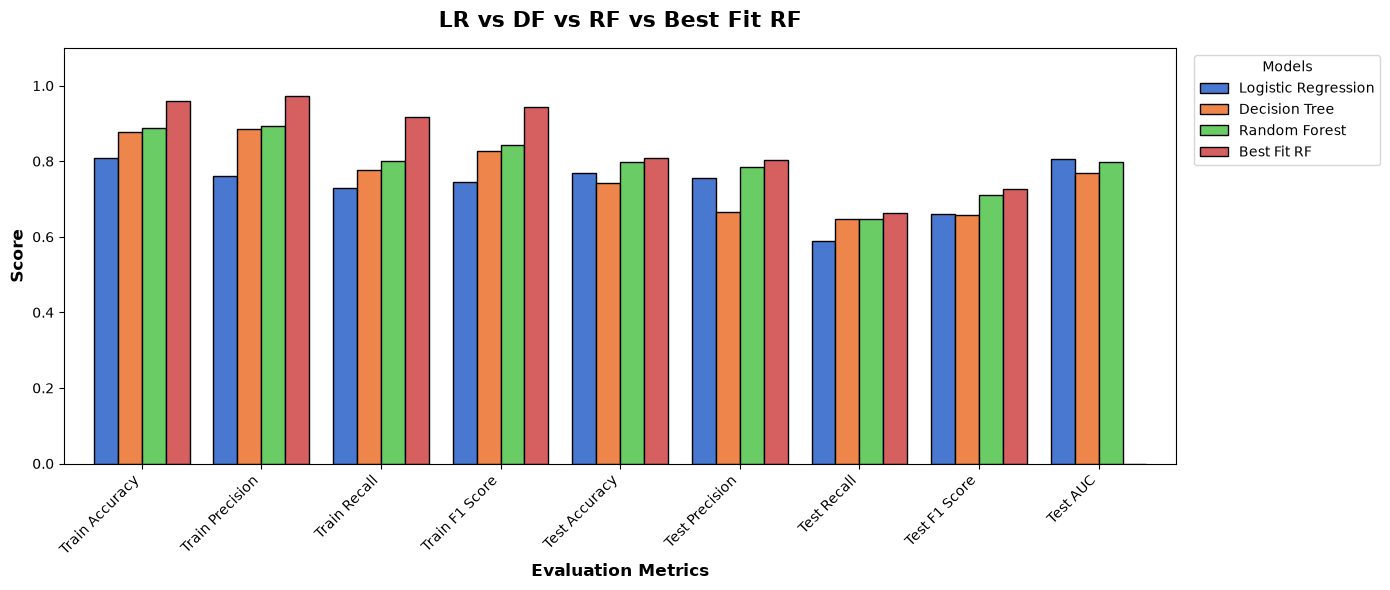

OOB Score of the model -  0.8305084745762712


In [29]:
# Hyperparameter Tuning
# Using RandomForestClassifier
print("Instantiate the RandomForestClassifier pipeline")
pipe_rf = Pipeline(
    steps=[
        ('preprocessor', col_transformer),
        ('model', RandomForestClassifier(random_state=42, oob_score=True))
    ]
)

print("Initialising the grid search object.....")
hyper_param_grid = {
    'model__max_depth': [4, 6, 8, 10, None],
    'model__n_estimators': [50, 100, 150]
}
k_fold = 5
grid_search_cv = GridSearchCV(estimator=pipe_rf, param_grid=hyper_param_grid, cv=k_fold, scoring='f1')

print("Performing Grid Search....")
grid_search_cv.fit(X_train, y_train)

print("Best Parameters:", grid_search_cv.best_params_)
print("Best F1 Score:", grid_search_cv.best_score_)
print("-" * 10)

print("Instantiate the random forest clasifier with these parametres")
pipe = Pipeline(
    steps=[
        ('preprocessor', col_transformer),
        ('model', RandomForestClassifier(max_depth=10, n_estimators=50, random_state=42, oob_score=True))
    ]
)

print("Train the best fit model....")
pipe.fit(X_train, y_train)

print(f"Testing with Training data....")
y_train_smote_pred = pipe.predict(X_train)

best_fit_stats = {}
# Get the best model parameters
best_fit_stats["Train Accuracy"] = accuracy_score(y_train, y_train_smote_pred)
best_fit_stats["Train Precision"] = precision_score(y_train, y_train_smote_pred)
best_fit_stats["Train Recall"] = recall_score(y_train, y_train_smote_pred)
best_fit_stats["Train F1 Score"] = f1_score(y_train, y_train_smote_pred)

print(f"Testing with Test data....")
y_test_smote_pred = pipe.predict(X_test)

best_fit_stats["Test Accuracy"] = accuracy_score(y_test, y_test_smote_pred)
best_fit_stats["Test Precision"] = precision_score(y_test, y_test_smote_pred)
best_fit_stats["Test Recall"] = recall_score(y_test, y_test_smote_pred)
best_fit_stats["Test F1 Score"] = f1_score(y_test, y_test_smote_pred)

filtered_stats["Best Fit RF"] = best_fit_stats
filtered_stats["Best Fit RF"]["Test AUC"] = 0

print("Publishing Results...")
df_best_fit = pd.DataFrame(filtered_stats)
fig, ax = plt.subplots(figsize=(14, 6))
df_best_fit.plot(kind='bar', ax=ax, width=0.8, color=sns.color_palette("muted"), edgecolor='black')
ax.set_title('LR vs DF vs RF vs Best Fit RF', fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('Score', fontweight='bold', fontsize=12)
ax.set_xlabel('Evaluation Metrics', fontweight='bold', fontsize=12)
ax.set_ylim(0, 1.1) 
plt.xticks(rotation=45, ha='right')
ax.legend(title='Models', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

#OOB score for the model
print("OOB Score of the model - ", pipe.named_steps['model'].oob_score_)

Training the regression model....
Predictions on test data...
Linear Regression Metrics:
-----------------------------------
MAE:                19.6006
RMSE:               30.3000
R-squared:          0.4336
Adjusted R-squared: 0.4033
-----------------------------------


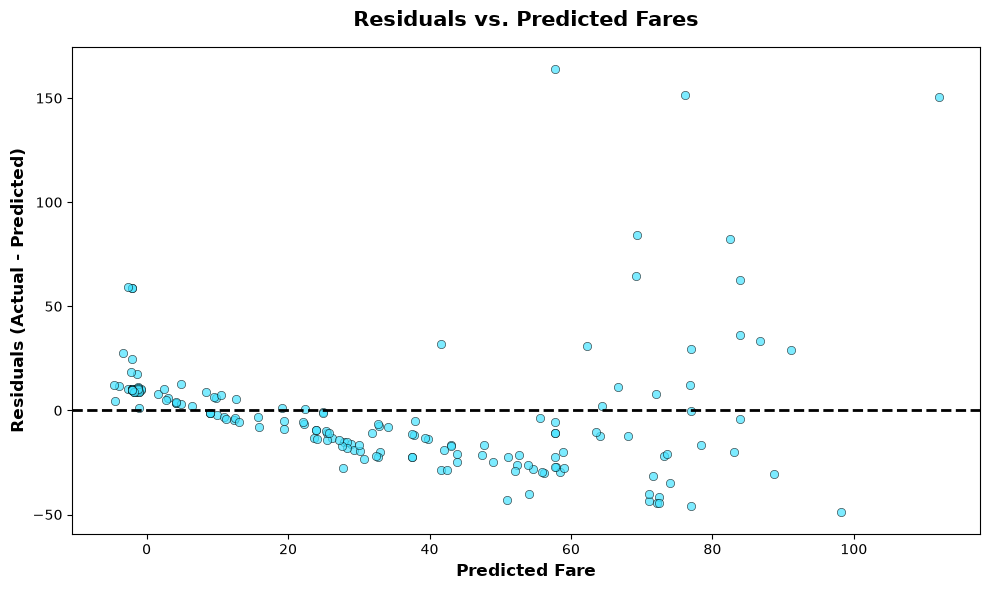

'According to the residual plot, instead of forming a random, uniformly distributed band around the zero-line, \nthe vertical spread of the residuals widens significantly as the predicted fare increases, \ncreating a distinct funnel or cone shape, hence the plot clearly shows heteroscedasticity'

In [36]:
# Regression side task
# Determining X and y for this task and make the column fare as y and remaining columns as X
X_reg = df.drop(columns=['fare', 'survived'])
y_reg = df['fare']
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, 
    test_size=0.2, 
    random_state=42
)
 # split the data for tsting and tarining and setup a Columntransformer and pipeline
X_reg = df.drop(columns=['fare', 'survived'])
y_reg = df['fare']
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, 
    test_size=0.2, 
    random_state=42
)
categorial_cols_reg = ['sex', 'embarked']
numerical_cols_reg = ['age', 'sibsp', 'parch', 'pclass']

col_transformer_reg = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols_reg),
        ('cat', OneHotEncoder(), categorial_cols_reg)
    ],
    remainder='passthrough'
)

pipe_reg = Pipeline(
    steps=[
        ('preprocessor', col_transformer_reg),
        ('model', LinearRegression())
    ]
)

# Train the Linear Regression model with this data and evaluate metrics MAE, RMSE, R2
print("Training the regression model....")
pipe_reg.fit(X_train_reg, y_train_reg)
print("Predictions on test data...")
y_pred_reg = pipe_reg.predict(X_test_reg)
# Calculate Regression Metrics
mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)
n = len(y_test_reg) 
p = pipe_reg.named_steps['preprocessor'].transform(X_test_reg).shape[1] 
adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
print("Linear Regression Metrics:")
print("-" * 35)
print(f"MAE:                {mae:.4f}")
print(f"RMSE:               {rmse:.4f}")
print(f"R-squared:          {r2:.4f}")
print(f"Adjusted R-squared: {adj_r2:.4f}")
print("-" * 35)

# Producing a residual plot
residuals = y_test_reg - y_pred_reg

fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot of Predicted Values vs. Residuals
sns.scatterplot(x=y_pred_reg, y=residuals, alpha=0.7, color="#46E3FF", edgecolor='black', ax=ax)

# Draw a red baseline at Y=0 (perfect prediction)
ax.axhline(0, color='black', linestyle='--', linewidth=2)

ax.set_title('Residuals vs. Predicted Fares', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Fare', fontweight='bold', fontsize=12)
ax.set_ylabel('Residuals (Actual - Predicted)', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()
"""According to the residual plot, instead of forming a random, uniformly distributed band around the zero-line, 
the vertical spread of the residuals widens significantly as the predicted fare increases, 
creating a distinct funnel or cone shape, hence the plot clearly shows heteroscedasticity"""

In [37]:
# Model Comparsion Table
# Defining the metric names to extract
classification_metrics = [
    'Test Accuracy', 
    'Test Precision', 
    'Test Recall', 
    'Test F1 Score'
]
# Loop through metrics from 'metrics' dictionary
table_data = []
for metric in classification_metrics:
    row = {
        'Model Type': 'Classification',
        'Evaluation Metric': metric,
        'Logistic Regression': f"{stats['Logistic Regression'].get(metric, 0):.4f}",
        'Decision Tree': f"{stats['Decision Tree'].get(metric, 0):.4f}",
        'Random Forest': f"{stats['Random Forest'].get(metric, 0):.4f}",
        'Linear Regression': '-'
    }
    table_data.append(row)

regression_metrics = {
    'MAE': mae,
    'RMSE': rmse,
    'R²': r2,
    'Adjusted R²': adj_r2
}
# Loop through regression metrics and add to the table
for metric_name, value in regression_metrics.items():
    row = {
        'Model Type': 'Regression',
        'Evaluation Metric': metric_name,
        'Logistic Regression': '-',
        'Decision Tree': '-',
        'Random Forest': '-',
        'Linear Regression': f"{value:.4f}"
    }
    table_data.append(row)

# Convert to a Pandas DataFrame
comparison_df = pd.DataFrame(table_data)
# Print the metrics
print("\n" + "-" * 125)
print("FINAL MODEL COMPARISON RESULTS".center(110))
print("-" * 125)
print(comparison_df.to_string(index=False, justify='left', col_space=20))
print("-" * 125 + "\n")


-----------------------------------------------------------------------------------------------------------------------------
                                        FINAL MODEL COMPARISON RESULTS                                        
-----------------------------------------------------------------------------------------------------------------------------
Model Type           Evaluation Metric    Logistic Regression  Decision Tree        Random Forest        Linear Regression   
Classification        Test Accuracy       0.7697               0.7416               0.7978                     -             
Classification       Test Precision       0.7547               0.6667               0.7857                     -             
Classification          Test Recall       0.5882               0.6471               0.6471                     -             
Classification        Test F1 Score       0.6612               0.6567               0.7097                     -             
    Re

In [38]:
# Complete Pipeline
# Reinitiate the best model and fit the train data and saving it as .pkl file
pipe = Pipeline(
    steps=[
        ('preprocessor', col_transformer),
        ('model', RandomForestClassifier(max_depth=10, n_estimators=50, random_state=42, oob_score=True))
    ]
)

print("Train the best fit model....")
pipe.fit(X_train, y_train)
# Save the model
joblib.dump(pipe, 'best_titanic_pipeline.pkl')
print("Pipeline saved successfully to 'best_titanic_pipeline.pkl'")
# Reload the pipeline from the file and check that against the data
loaded_pipeline = joblib.load('best_titanic_pipeline.pkl')
print("Pipeline loaded successfully!\n")
sample_test = X_test.head(5)
sample_label = y_test.head(5)
predictions = loaded_pipeline.predict(sample_test)
probabilities = loaded_pipeline.predict_proba(sample_test)[:, 1]
print("Raw Input Data:")
print(sample_test.to_string())
print("\nResults:")
for i, (pred, prob, actual) in enumerate(zip(predictions, probabilities, sample_label)):
    status = "Survived" if pred == 1 else "Died"
    actual_status = "Survived" if actual == 1 else "Died"
    print(f"Passenger {i+1}: Predicted to {status} (Survival Probability: {prob:.2f}) Actual being {actual_status}")

Train the best fit model....
Pipeline saved successfully to 'best_titanic_pipeline.pkl'
Pipeline loaded successfully!

Raw Input Data:
     pclass   sex   age  sibsp  parch     fare embarked
125       3  male  28.0      0      0   7.7500        Q
858       3  male  41.0      2      0  14.1083        S
751       3  male  33.0      0      0   9.5000        S
564       3  male  24.0      2      0  24.1500        S
427       3  male  28.0      0      0   7.7500        Q

Results:
Passenger 1: Predicted to Died (Survival Probability: 0.21) Actual being Died
Passenger 2: Predicted to Died (Survival Probability: 0.06) Actual being Died
Passenger 3: Predicted to Died (Survival Probability: 0.22) Actual being Died
Passenger 4: Predicted to Died (Survival Probability: 0.17) Actual being Died
Passenger 5: Predicted to Died (Survival Probability: 0.21) Actual being Died
